# Week 6: Regression
## Project Tasks:
- Finalize any remaining feature work.
- Apply Regression model (e.g., linear regression to predict emotional intensity from audio features)
- Evaluate with regression metrics (MSE, R²). Begin implementing Logistic Regression in MiniLearn

In [12]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")
from minilearn import StandardScaler, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data_folder = "../data"
fpath = os.path.join(data_folder, "week5_audio.csv")

feature_df = pd.read_csv(fpath)

feature_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,...,spectral_rolloff_std,spectral_rolloff_min,spectral_rolloff_max,path,filename,emotion,intensity,actor,gender,vocal_channel
0,-726.21720,157.85083,-861.53260,-432.15480,68.54142,84.219345,-85.970474,236.70389,3.293398,20.393255,...,7873.634242,0.0000,20929.6875,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutral,normal,1,male,speech
1,-719.12830,159.35600,-861.44400,-417.70416,70.20157,78.612820,-14.972853,218.36372,1.168397,23.063353,...,7634.107567,960.9375,21140.6250,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutral,normal,1,male,speech
2,-714.99570,162.87424,-851.23380,-412.74353,69.68935,85.796005,-45.141598,229.02920,3.924564,17.979307,...,7981.393363,0.0000,21140.6250,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutral,normal,1,male,speech
3,-710.97530,161.77583,-847.86710,-388.34793,67.56488,78.593960,-37.103306,216.24066,5.782241,20.279503,...,7570.671093,937.5000,21187.5000,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutral,normal,1,male,speech
4,-759.92175,162.98659,-917.40265,-454.39650,75.78352,78.566280,-18.632597,230.43222,6.023605,23.161620,...,7902.073642,0.0000,21585.9375,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,calm,normal,1,male,speech


In [ ]:
m_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
f_cols = []

for c in feature_df.columns:
    if c not in m_cols:
        f_cols.append(c)

if len(feature_df) >0:
    intensity_num = feature_df["intensity"].replace({"normal": 0, "strong": 1})
    X = feature_df[f_cols]
    y = intensity_num

In [8]:
if len(feature_df) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train)
    X_test_scale = scaler.transform(X_test)

In [13]:
if len(feature_df) > 0:
    lin_regres = LinearRegression()
    lin_regres.fit(X_train_scale, y_train)
    ypred = lin_regres.predict(X_test_scale)
    mse = mean_squared_error(y_test, ypred)
    r2 = r2_score(y_test, ypred)

    print("MSE: ", mse)
    print("R2: ", r2)

MSE:  680278.9560780703
R2:  -2737232.2373134647


Text(0, 0.5, 'Predicted')

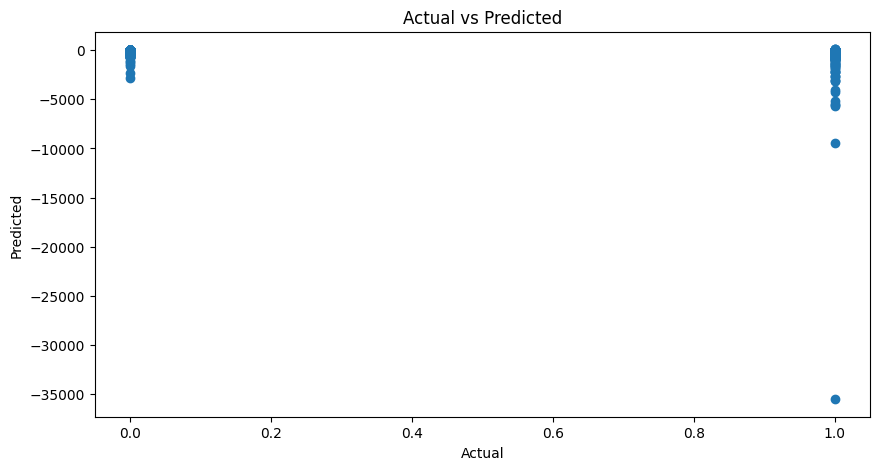

In [14]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,ypred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
